# Observables
Let $\tilde{S}_{iy}$ be the "raw" size of firm $i$ at year $y$, we then normalize it by dividing it with the average market size at that time
$$
S_{iy} = N_y \frac{\tilde{S}_{iy}}{\sum_i \tilde{S}_{iy}}
$$
where $N_y$ is the number of observation in a "year", it's always equal to $N$ is our case

then we define the growth rate as
$$
g_{iy} = \ln\left(\frac{S_{iy+1}}{S_{iy}}\right) = \ln(S_{iy+1}) - \ln(S_{iy}) =  \ln(\tilde{S}_{iy+1}) - \ln(\tilde{S}_{iy}) + \left[\ln\left(\sum_i \tilde{S}_{iy}\right) -  \ln\left(\sum_i \tilde{S}_{iy+1}\right) \right]
$$
from this the growth volatility is calculated using the adjusted mean absolute deviation
$$
\sigma_i = \sqrt{\frac{\pi}{2}} \frac{1}{T_i} \sum_y |g_{iy} - \bar{g}_i|
$$


In the paper "Firm-level production networks: what do we (really) know?" by Bacilieri et al. they describe the average degree in the network scaling as
$$
\bar{k} \sim N^{\eta}
$$
where $\eta \approx 0.13$

In [47]:
import numpy as np
import glv
from scipy.stats import truncnorm
from scipy.integrate import solve_ivp

In [48]:
# Parameters
N     = 10_000
C     = 50
sigma = 0.2
gamma = 0.0

degree_sequence = np.maximum(np.random.exponential(scale=C, size=N).astype(int), 1)
if np.sum(degree_sequence) % 2 != 0:
    degree_sequence[0] += 1

nu_pdf = lambda g: np.exp(-g)  # exponential degree distribution
mu_c   = glv.calculate_mu_c(sigma=sigma, gamma=gamma, nu_pdf=nu_pdf)["mu_c"] 
print(f"mu_c = {mu_c:.4f}")

mu_c = 0.4990


In [49]:
def find_empirical_mu_c(N, C, sigma, seed, mu_theory, tol=1e-3):
    low = mu_theory * 0.5
    high = mu_theory * 1.5
    empirical_mu_c = mu_theory
    
    # Increase test time to let the divergence manifest
    tau_test = 20_000 
    
    for _ in range(15):
        mid = (low + high) / 2.0
        
        # Recreate exact initial conditions
        rng = np.random.default_rng(seed)
        np.random.seed(seed)
        
        deg = np.maximum(rng.exponential(scale=C, size=N).astype(int), 1)
        if deg.sum() % 2 != 0:
            deg[0] += 1
            
        W = glv.generate_matrix(deg, C, mu=mid, sigma=sigma)
        
        x0 = rng.uniform(0.1, 1.0, N)
        M0 = x0.sum()
        state0 = np.concatenate((x0 / M0, [M0], [0.0]))
        
        sol = solve_ivp(
            fun=glv.rescaled_glv_sparse,
            t_span=(0, tau_test),
            y0=state0,
            args=(N, W),
            method='RK45',
            max_step=100.0,
        )
        
        M_final = sol.y[N, -1]
        
        # ROBUST CHECK: If the solver breaks OR M becomes 5x larger than initial,
        # it is definitively diverging (we are above mu_c)
        if not sol.success or M_final > M0 * 5.0:
            high = mid
            empirical_mu_c = mid
        else:
            # It stabilized (we are below mu_c)
            low = mid
            
        if (high - low) < tol:
            break
            
    return empirical_mu_c

In [50]:
# Aggregate over many independent realizations to suppress single-run bias.
# Each realization: fresh degree sequence, fresh interaction matrix, fresh ICs.
def run_realization(N, C, sigma, mu, n_snaps, tau_max, seed):
    rng = np.random.default_rng(seed)
    np.random.seed(seed)  # generate_matrix uses np.random global state

    deg = np.maximum(rng.exponential(scale=C, size=N).astype(int), 1)
    if deg.sum() % 2 != 0:
        deg[0] += 1

    W = glv.generate_matrix(deg, C, mu=mu, sigma=sigma)

    x0 = rng.uniform(0.1, 1.0, N)
    M0 = x0.sum()
    state0 = np.concatenate((x0 / M0, [M0], [0.0]))

    sol = solve_ivp(
        fun=glv.rescaled_glv_sparse,
        t_span=(0, tau_max),
        y0=state0,
        args=(N, W),
        dense_output=True,
        method='RK45',
        max_step=1e2,
    )
    if not sol.success:
        return None

    tau_grid = sol.t
    t_grid   = sol.y[N + 1, :]
    t_snaps   = np.linspace(t_grid[0], t_grid[-1], n_snaps)
    tau_snaps = np.interp(t_snaps, t_grid, tau_grid)

    snap = sol.sol(tau_snaps)
    Y = snap[:N, :]
    M = snap[N, :]
    X_raw = Y * M

    floor = 1e-20
    alive = X_raw.min(axis=1) > floor

    S_all = N * X_raw / X_raw.sum(axis=0, keepdims=True)
    S = S_all[alive, :]

    g_r = np.diff(np.log(S), axis=1)
    g_bar = g_r.mean(axis=1, keepdims=True)
    vol_r  = np.sqrt(np.pi / 2) * np.abs(g_r - g_bar).mean(axis=1)
    size_r = S.mean(axis=1)

    return g_r.ravel(), size_r, vol_r, int(alive.sum())


n_realizations = 5
n_snaps_run    = 100
tau_max_run    = 5e5

# Running histogram so memory stays O(bins) instead of O(N * n_snaps * runs).
bin_edges  = np.linspace(-10.0, 10.0, 401)
hist_counts = np.zeros(bin_edges.size - 1, dtype=np.int64)

sizes_agg, vols_agg = [], []
n_alive_agg = 0

for r in range(n_realizations):
    current_seed = 1000 + r
    
    print(f"Realization {r+1}: Calibrating exact empirical mu_c...")
    
    # 1. Find the exact tipping point for this specific random network
    exact_mu_c = find_empirical_mu_c(N=N, C=C, sigma=sigma, 
                                     seed=current_seed, mu_theory=mu_c)
    
    # 2. Set the run slightly above the empirical critical point
    # Instead of 5% (1.05), we can now safely run just above it (e.g. + 0.005)
    mu_run_exact = exact_mu_c + 0.001
    print(f"  -> Found exact mu_c = {exact_mu_c:.4f}. Running full sim at mu = {mu_run_exact:.4f}")

    out = run_realization(
        N=N, C=C, sigma=sigma, mu=mu_run_exact,
        n_snaps=n_snaps_run, tau_max=tau_max_run,
        seed=current_seed,
    )
    if out is None:
        print(f"  realization {r+1}: integration failed, skipping")
        continue
    g_flat_r, size_r, vol_r, n_alive = out
    c, _ = np.histogram(g_flat_r, bins=bin_edges)
    hist_counts += c
    sizes_agg.append(size_r)
    vols_agg.append(vol_r)
    n_alive_agg += n_alive
    print(f"  realization {r+1}/{n_realizations}: alive={n_alive}/{N}, |g|={g_flat_r.size}")

sizes_agg = np.concatenate(sizes_agg)
vols_agg  = np.concatenate(vols_agg)

bin_widths  = np.diff(bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
g_density   = hist_counts / (hist_counts.sum() * bin_widths)

print(f"total surviving firms across runs: {n_alive_agg}")


Realization 1: Calibrating exact empirical mu_c...
  -> Found exact mu_c = 0.5838. Running full sim at mu = 0.5848
  realization 1/5: alive=10000/10000, |g|=990000
Realization 2: Calibrating exact empirical mu_c...
  -> Found exact mu_c = 0.5672. Running full sim at mu = 0.5682
  realization 2/5: alive=9999/10000, |g|=989901
Realization 3: Calibrating exact empirical mu_c...
  -> Found exact mu_c = 0.5740. Running full sim at mu = 0.5750
  realization 3/5: alive=10000/10000, |g|=990000
Realization 4: Calibrating exact empirical mu_c...
  -> Found exact mu_c = 0.5857. Running full sim at mu = 0.5867
  realization 4/5: alive=9999/10000, |g|=989901
Realization 5: Calibrating exact empirical mu_c...
  -> Found exact mu_c = 0.5877. Running full sim at mu = 0.5887
  realization 5/5: alive=10000/10000, |g|=990000
total surviving firms across runs: 49998


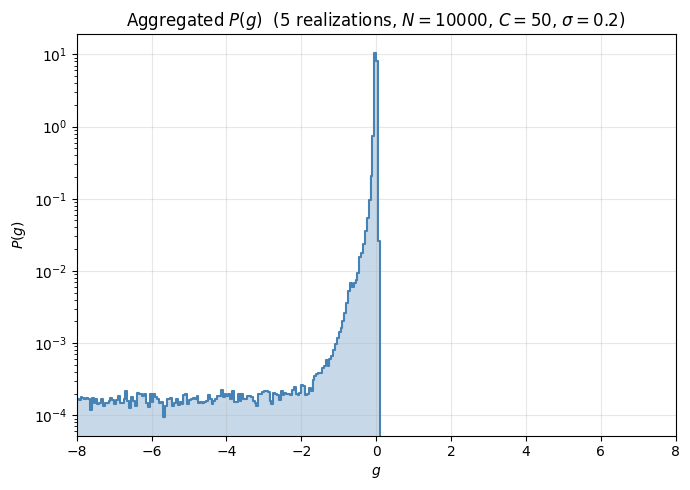

In [51]:
import matplotlib.pyplot as plt
# Aggregated growth-rate distribution
fig, ax = plt.subplots(figsize=(7, 5))
ax.step(bin_centers, g_density, where='mid', color='steelblue')
ax.fill_between(bin_centers, g_density, step='mid', alpha=0.3, color='steelblue')
ax.set_yscale('log')
ax.set_xlim(-8, 8)
ax.set_xlabel(r'$g$')
ax.set_ylabel(r'$P(g)$')
ax.set_title(f'Aggregated $P(g)$  ({n_realizations} realizations, $N={N}$, $C={C}$, $\\sigma={sigma}$)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


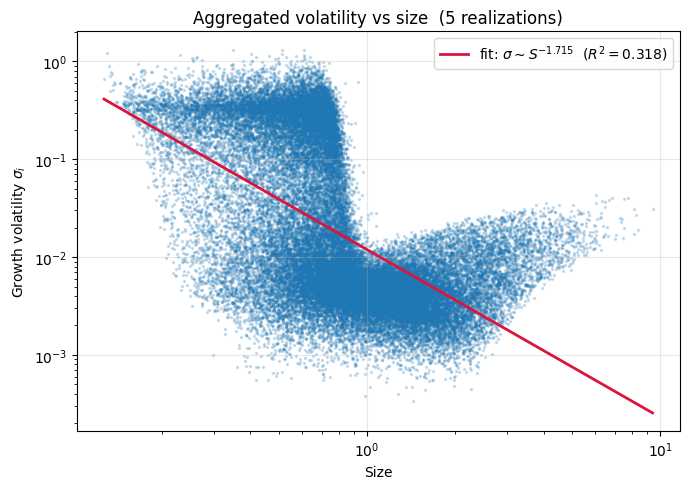

beta = -1.7152,  intercept (log10) = -1.9238,  R^2 = 0.3185


In [52]:
# Aggregated volatility vs size, with log-log linear fit (sigma ~ S^beta)
fit_mask = (sizes_agg > 0) & (vols_agg > 0)
log_S = np.log10(sizes_agg[fit_mask])
log_v = np.log10(vols_agg[fit_mask])
beta, log_a = np.polyfit(log_S, log_v, 1)
ss_res = np.sum((log_v - (beta * log_S + log_a)) ** 2)
ss_tot = np.sum((log_v - log_v.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot

S_line = np.logspace(log_S.min(), log_S.max(), 200)
v_line = 10 ** log_a * S_line ** beta

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sizes_agg, vols_agg, s=2, alpha=0.2)
ax.plot(S_line, v_line, color='crimson', lw=2,
        label=fr'fit: $\sigma \sim S^{{{beta:.3f}}}$  ($R^2={r2:.3f}$)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Size')
ax.set_ylabel(r'Growth volatility $\sigma_i$')
ax.set_title(f'Aggregated volatility vs size  ({n_realizations} realizations)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'beta = {beta:.4f},  intercept (log10) = {log_a:.4f},  R^2 = {r2:.4f}')


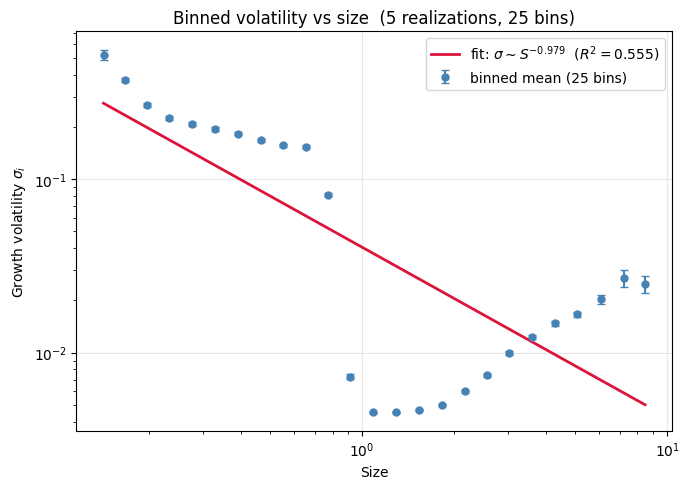

binned beta = -0.9794,  intercept (log10) = -1.3918,  R^2 = 0.5553


In [53]:
# Binned aggregated volatility vs size: 25 log-spaced bins on size
n_bins = 25
pos = (sizes_agg > 0) & (vols_agg > 0)
S_pos = sizes_agg[pos]
v_pos = vols_agg[pos]

bin_edges_S = np.logspace(np.log10(S_pos.min()), np.log10(S_pos.max()), n_bins + 1)
bin_idx = np.digitize(S_pos, bin_edges_S) - 1
bin_idx = np.clip(bin_idx, 0, n_bins - 1)

S_bin_mean = np.full(n_bins, np.nan)
v_bin_mean = np.full(n_bins, np.nan)
v_bin_err  = np.full(n_bins, np.nan)
counts     = np.zeros(n_bins, dtype=int)

for b in range(n_bins):
    sel = bin_idx == b
    counts[b] = sel.sum()
    if counts[b] > 0:
        S_bin_mean[b] = S_pos[sel].mean()
        v_bin_mean[b] = v_pos[sel].mean()
        v_bin_err[b]  = v_pos[sel].std(ddof=1) / np.sqrt(counts[b]) if counts[b] > 1 else 0.0

valid = counts > 0
log_Sb = np.log10(S_bin_mean[valid])
log_vb = np.log10(v_bin_mean[valid])
beta_b, log_a_b = np.polyfit(log_Sb, log_vb, 1)
ss_res_b = np.sum((log_vb - (beta_b * log_Sb + log_a_b)) ** 2)
ss_tot_b = np.sum((log_vb - log_vb.mean()) ** 2)
r2_b = 1.0 - ss_res_b / ss_tot_b

S_line_b = np.logspace(log_Sb.min(), log_Sb.max(), 200)
v_line_b = 10 ** log_a_b * S_line_b ** beta_b

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(S_bin_mean[valid], v_bin_mean[valid], yerr=v_bin_err[valid],
            fmt='o', color='steelblue', ecolor='steelblue', capsize=3,
            markersize=5, label=f'binned mean ({n_bins} bins)')
ax.plot(S_line_b, v_line_b, color='crimson', lw=2,
        label=fr'fit: $\sigma \sim S^{{{beta_b:.3f}}}$  ($R^2={r2_b:.3f}$)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Size')
ax.set_ylabel(r'Growth volatility $\sigma_i$')
ax.set_title(f'Binned volatility vs size  ({n_realizations} realizations, {n_bins} bins)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'binned beta = {beta_b:.4f},  intercept (log10) = {log_a_b:.4f},  R^2 = {r2_b:.4f}')


![](images/volatility_vs_size_bm.png)